# **Mission 3 - Exploratory Data Analysis (EDA) with the Sales Dataset using Pandas and d Matplotlib/Seaborn**

### **Objective:**

The goal of this assignment is to help you apply your knowledge of Python for basic operations, Pandas for data manipulation, and Matplotlib/Seaborn for visualizations. You'll be working with a real-world dataset, and your tasks will include loading the data, performing EDA, and visualising the results.

###  **Dataset**

The dataset represents transaction data from a retail business, specifically sales data for products sold in various stores. It contains multiple tables that provide insights into sales, invoices, and products. Let’s break down the tables and what they represent:

#### Sales Table:

InvoiceNo: The unique identifier for each invoice (or transaction).

StockCode: A unique identifier for each product.

Quantity: The number of units sold in each transaction.

UnitPrice: The price per unit of the product.

InvoiceDate: The date when the transaction occurred.

#### Invoice Table:

InvoiceNo: The same unique identifier for each invoice, linking the sales data with the invoice details.

Country: The country where the sale was made.

#### Product Table:

StockCode: A unique identifier for each product.

Description: The name or description of the product.

Product_Category: The category the product belongs to (e.g., "Gift", "Sign", "Mug").



You will need to merge them and perform the following tasks step by step.


### Task 1: Load the Excel File
#### Objective: Import the data from the provided Excel file into Python using Pandas.

Instructions:

1. Upload the provided excel file into Fabric environment
2. Read each sheet of the excel file as a separate dataframe. 
3. Name the dataframe for sales as df_sales, the dataframe for invoice as df_invoice and the dataframe for product as df_product
4. Display the first few rows of each DataFrame to understand its structure.



In [40]:

import pandas as pd

df_sales = pd.read_excel(f"{notebookutils.nbResPath}/builtin/Online Sales Retailer.xlsx", sheet_name='Sales')
df_invoice = pd.read_excel(f"{notebookutils.nbResPath}/builtin/Online Sales Retailer.xlsx", sheet_name='Invoice')
df_product = pd.read_excel(f"{notebookutils.nbResPath}/builtin/Online Sales Retailer.xlsx", sheet_name='Product')

print("Sales DataFrame:")
display(df_sales.head())

print("Invoice DataFrame:")
display(df_invoice.head())

print("Product DataFrame:")
display(df_product.head())

Sales DataFrame:


Invoice DataFrame:


Product DataFrame:


### Task 2: Basic Python and Pandas Operations
#### Objective: Perform basic Python and Pandas operations to manipulate the data.

<mark>Instructions:</mark>

1. Create the Sales Column (Quantity * Unit Price) 

2. Check for missing values in the Sales DataFrame.

3. Replace any NaN values in the Sales and UnitPrice columns with 0.

4. Calculate basic descriptive statistics for the Quantity and UnitPrice columns (mean, median, mode, standard deviation).

In [41]:
###Create the Sales Column (Quantity * Unit Price)

df_sales['Sales'] = df_sales['Quantity'] * df_sales['UnitPrice']

display(df_sales)

In [42]:
###Check for missing values in the Sales DataFrame

missing_values = df_sales[df_sales.isnull().any(axis=1)]

display(missing_values)

print("Number of rows with missing values:", len(missing_values))


Number of rows with missing values: 0


In [43]:
### Replace any NaN values in the Sales and UnitPrice columns with 0

df_sales['Sales'] = df_sales['Sales'].fillna(0)
df_sales['UnitPrice'] = df_sales['UnitPrice'].fillna(0)

display(df_sales[['Sales', 'UnitPrice']].isnull().sum())

In [44]:
### Calculate basic descriptive statistics for the Quantity and UnitPrice columns (mean, median, mode, standard deviation)

# Mean
print("Mean:")
display(df_sales[['Quantity', 'UnitPrice']].mean())

# Median
print("Median:")
display(df_sales[['Quantity', 'UnitPrice']].median())

# Mode
print("Mode:")
display(df_sales[['Quantity', 'UnitPrice']].mode())

# Standard Deviation
print("Standard Deviation:")
display(df_sales[['Quantity', 'UnitPrice']].std())

Mean:


Median:


Mode:


Standard Deviation:


### Task 3: Merging DataFrames
#### Objective: Merge the Sales, Invoice, and Product tables based on common keys to perform a comprehensive analysis.

Instructions:

1. Merge the Sales DataFrame with the Invoice DataFrame on InvoiceNo.

2. Merge the result with the Product DataFrame on StockCode

In [45]:
## Merge the Sales DataFrame with the Invoice DataFrame on InvoiceNo

df_combined = pd.merge(df_sales, df_invoice, on='InvoiceNo')

display(df_combined)

In [46]:
### Merge the result with the Product DataFrame on StockCode

df_df_combined = pd.merge(df_combined, df_product, on='StockCode')

display(df_df_combined)

## Task 4: Exploratory Data Analysis (EDA)
### Objective: Conduct EDA by analysing the data, identifying patterns, trends, and outliers.

Instructions:

Use describe() to calculate summary statistics for numeric columns.

Perform basic filtering, such as filtering out sales with Quantity equal to 0.

Check for outliers in the Sales column by using a scatter plot.

In [47]:
### Use describe() to calculate summary statistics for numeric columns

df_combined[['Quantity', 'UnitPrice', 'Sales']].describe()

,Quantity,UnitPrice,Sales
count,83277.000000,83277.000000,83277.000000
mean,13.610961,3.083503,23.121043
std,261.577565,5.177653,278.041319
min,1.000000,0.000000,0.000000
25%,2.000000,1.250000,5.000000
50%,6.000000,1.950000,12.500000
75%,12.000000,3.750000,19.500000
max,74215.000000,295.000000,77183.600000


In [48]:
### Perform basic filtering, such as filtering out sales with Quantity equal to 0

df_filtered = df_df_combined[df_df_combined['Quantity'] != 0]
display(df_filtered)

print("Rows before filtering:", len(df_df_combined))
print("Rows after filtering:", len(df_filtered))


Rows before filtering: 83277
Rows after filtering: 83277


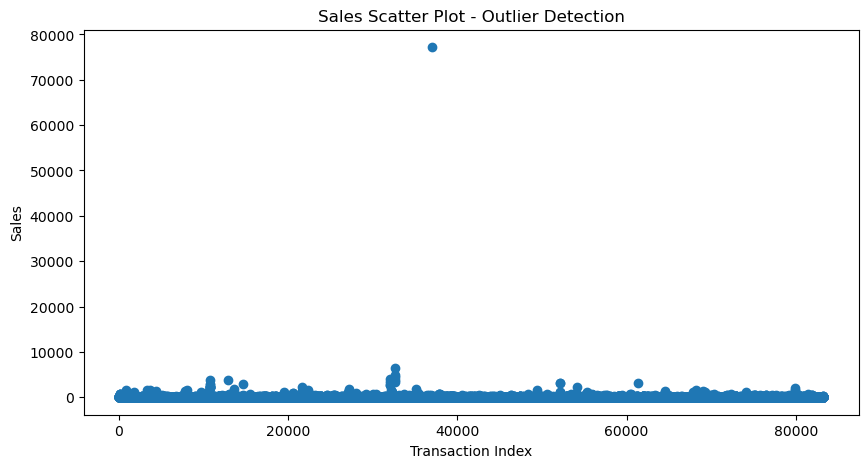

In [49]:
## Check for outliers in the Sales column by using a scatter plot.

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.scatter(df_filtered.index, df_filtered['Sales'])

plt.xlabel('Transaction Index')
plt.ylabel('Sales')
plt.title('Sales Scatter Plot - Outlier Detection')

plt.show()

## Task 5: Data Visualisation – Scatter Plot, Histogram, and Line Chart
### Objective: Create scatter plots, histograms, and line charts to better understand the data.

Instructions:

Use a scatter plot to examine the relationship between Quantity and Sales.

Use a histogram to visualise the distribution of the Sales column.

Use a line chart to show the trend of Sales over time.

Write 1–2 sentences explaining the insights from each visualisation.

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

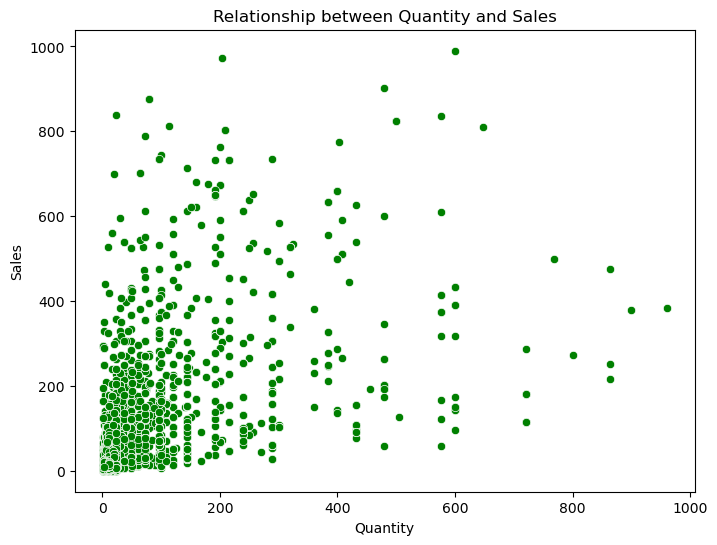

In [51]:
## Use a scatter plot to examine the relationship between Quantity and Sales

import seaborn as sns
import matplotlib.pyplot as plt

# Filter out the extreme outlier
df_plot = df_df_combined[
    (df_df_combined['Quantity'] < 1000) &
    (df_df_combined['Sales'] < 1000)
]

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x='Quantity',
    y='Sales',
    data=df_plot,
    color='green'
)

plt.title('Relationship between Quantity and Sales')
plt.xlabel('Quantity')
plt.ylabel('Sales')

plt.show()

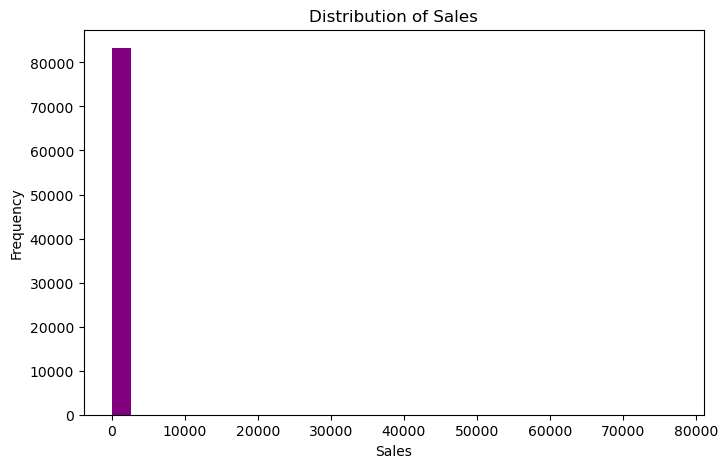

In [52]:
### Use a histogram to visualise the distribution of the Sales column

plt.figure(figsize=(8, 5))

plt.hist(df_df_combined['Sales'] , bins=30, color='purple')

plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.title('Distribution of Sales')

plt.show()

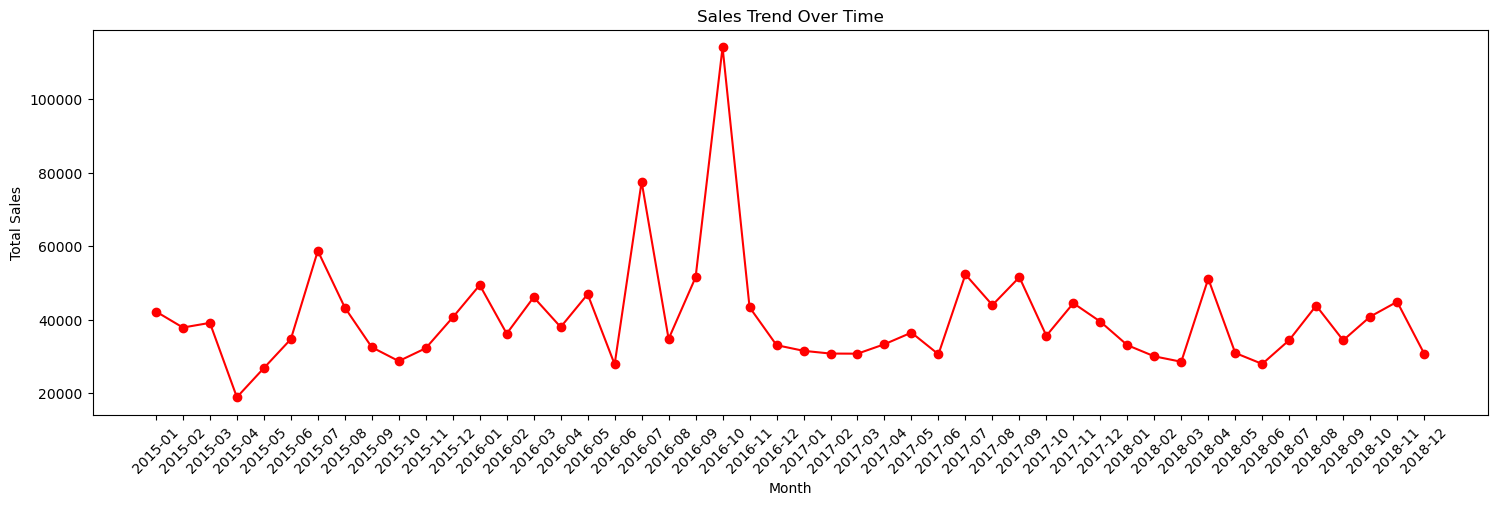

In [53]:
### Use a line chart to show the trend of Sales over time

sales_over_time = df_df_combined.groupby(
    df_df_combined['InvoiceDate'].dt.to_period('M')
)['Sales'].sum()

plt.figure(figsize=(18, 5))
plt.plot(sales_over_time.index.astype(str), sales_over_time.values, marker='o', color='red')

plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.title('Sales Trend Over Time')

plt.xticks(rotation=45)
plt.show()

### Write 1–2 sentences explaining the insights from each visualisation.

Scatter plot chart: I can see that sales generally increase as quantity increases. There are also some differences between the points, so not all transactions follow the same pattern.

Histogram chart insight: Most of the sales values are grouped at the lower end of the chart. There are only a few transactions with very high sales values, which makes the distribution spread out to the right.

Line chart :Sales change quite a lot from month to month. The highest sales can be seen around September 2016, while some of the lowest sales occurred in 2015 and early 2016.



In [1]:
### Write 1–2 sentences explaining the insights from each visualisation.

Scatter plot chart: I can see that sales generally increase as quantity increases. There are also some differences between the points, so not all transactions follow the same pattern.

Histogram chart insight: Most of the sales values are grouped at the lower end of the chart. There are only a few transactions with very high sales values, which makes the distribution spread out to the right.

Line chart :Sales change quite a lot from month to month. The highest sales can be seen around September 2016, while some of the lowest sales occurred in 2015 and early 2016.



SyntaxError: invalid syntax (149105254.py, line 3)

## Task 6: Correlation and Data Insights
### Objective: Identify the relationship between different numerical columns in the dataset.

Instructions:

Calculate the correlation between Quantity and Sales.

Visualise the correlation matrix using a heatmap.

Write 1–2 sentences explaining the insights from the visualisation.

In [55]:
## ## Check for outliers in the Sales column by using a scatter plot

correlation =df_df_combined[['Quantity', 'Sales']].corr()

print("Correlation between Quantity and Sales:")
display(correlation)

Correlation between Quantity and Sales:


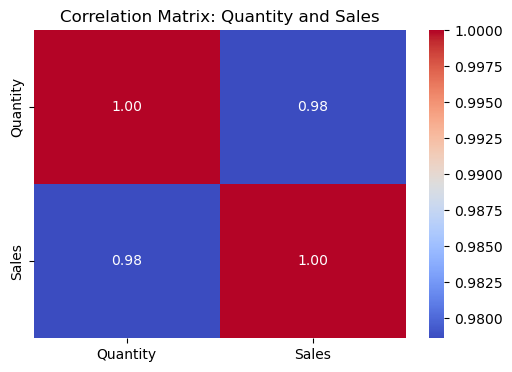

In [58]:
### Visualise the correlation matrix using a heatmap

correlation = df_df_combined[['Quantity', 'Sales']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix: Quantity and Sales')
plt.show()

In [ ]:
Write 1–2 sentences explaining the insights from the visualisation.

From the heatmap, I can see that Quantity and Sales are strongly related. The correlation is 0.98, which shows that higher quantities generally result in higher sales.

## Task 7: Grouping and Aggregating
### Objective: Perform grouping and aggregation operations to summarise the data.

Instructions:

GroupBy operation: Group by Product_Category and calculate the total Sales per category.

Create a Pivot Table to show Sales by Country and Product_Category.

In [60]:
## GroupBy operation: Group by Product_Category and calculate the total Sales per category

sales_by_category = df_df_combined.groupby('Product_Category')['Sales'].sum().reset_index()
sales_by_category = sales_by_category.sort_values(by='Sales', ascending=False)

display(sales_by_category)

In [63]:
### Create a Pivot Table to show Sales by Country and Product_Category

pivot_sales = pd.pivot_table(df_df_combined, values='Sales', index='Country', columns='Product_Category', aggfunc='sum', fill_value=0)

pivot_sales = pivot_sales.reset_index()

display(pivot_sales)

## Submission Guidelines:
Submit the Python notebook with all the tasks and visualisations.

Ensure that each task is clearly explained and that all steps are followed.

Include markdown explanations where necessary to explain your thought process.

Good Work, Joan.

Thanks Yasir :)